# Run Experiments Notebook

This notebook mirrors `scripts/run_experiments.py` while exposing the experiments as clean notebook cells. Run the cells from top to bottom. Each model cell trains one experiment, saves its figures in `outputs/figures/`, and updates the report files in `outputs/reports/`.


In [1]:
# Uncomment the next line in a fresh Colab runtime if dependencies are missing.
# %pip install -r requirements.txt

from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "config.py").exists() and (candidate / "scripts" / "run_experiments.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = locate_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments


In [2]:
import pandas as pd
from IPython.display import Image, display

from src.config import EXPERIMENT_SPECS, REPORTS_DIR, SEED
from src.experiment_runner import (
    prepare_experiment_context,
    results_summary_frame,
    run_experiment,
    upsert_result,
    write_experiment_reports,
)
from src.utils.common import set_global_seed

set_global_seed(SEED)
context = prepare_experiment_context()
spec_map = {spec.name: spec for spec in EXPERIMENT_SPECS}
results = []

summary_columns = [
    "name",
    "family",
    "hidden_layers",
    "standardize",
    "l2_lambda",
    "n_steps",
    "val_accuracy",
    "test_accuracy",
    "test_f1_macro",
]


def show_result(result: dict[str, object]) -> None:
    display(pd.DataFrame([{key: result[key] for key in summary_columns}]))
    print(f"History plot: {result['history_path']}")
    print(f"Confusion matrix: {result['confusion_matrix_path']}")
    display(Image(filename=result["history_path"]))
    display(Image(filename=result["confusion_matrix_path"]))


def run_and_log(spec_name: str) -> dict[str, object]:
    global results
    result = run_experiment(spec_map[spec_name], context)
    results = upsert_result(results, result)
    selection_summary = write_experiment_reports(results)
    show_result(result)
    print(f"Stored {len(results)} result(s). Reports updated in {REPORTS_DIR}.")
    best_name = selection_summary["best_overall_model"]["name"] if selection_summary["best_overall_model"] else None
    print(f"Current best overall model: {best_name}")
    return result


print("Notebook context is ready.")
print(f"Train shape: {context.dataset.X_train.shape}")
print(f"Validation shape: {context.dataset.X_val.shape}")
print(f"Test shape: {context.dataset.X_test.shape}")


Notebook context is ready.
Train shape: (5995, 16)
Validation shape: (1499, 16)
Test shape: (3498, 16)


## M1: NumPy Raw Baseline


,name,family,hidden_layers,standardize,l2_lambda,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m1_numpy_raw_baseline,numpy,"(32,)",False,0.0,11280,0.985991,0.961121,0.961161


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m1_numpy_raw_baseline_history.png
Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m1_numpy_raw_baseline_confusion_matrix.png


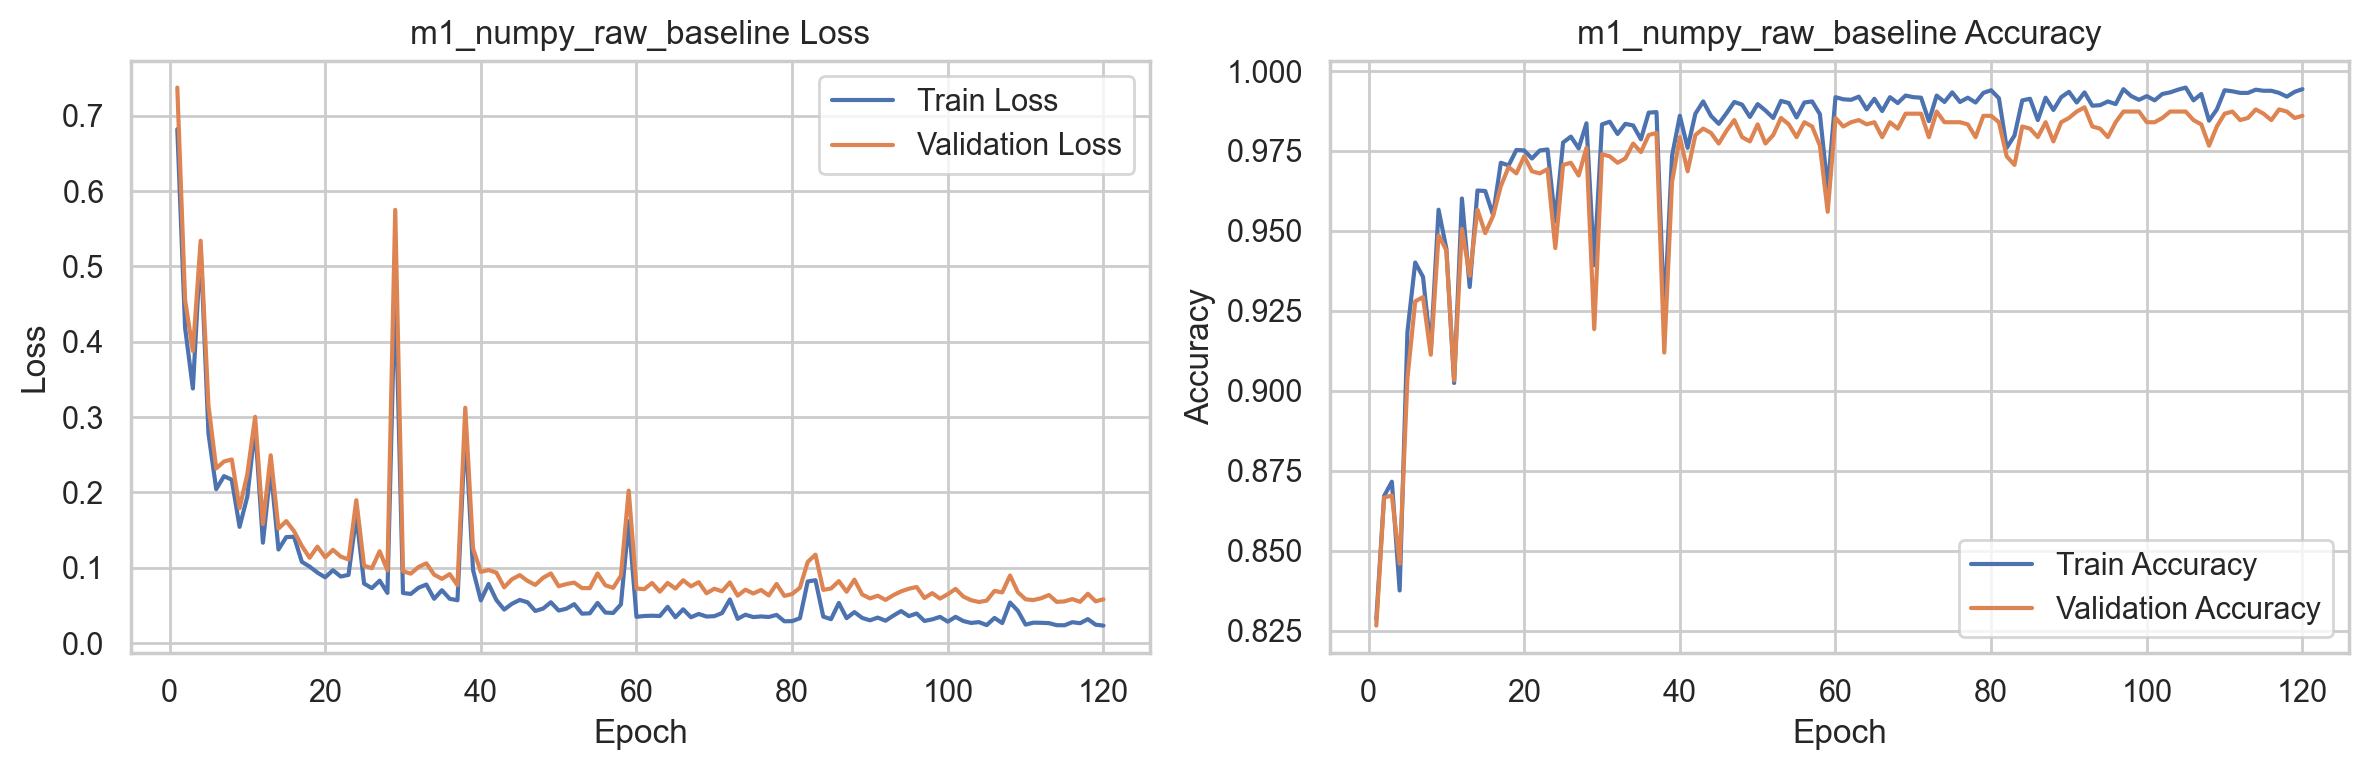

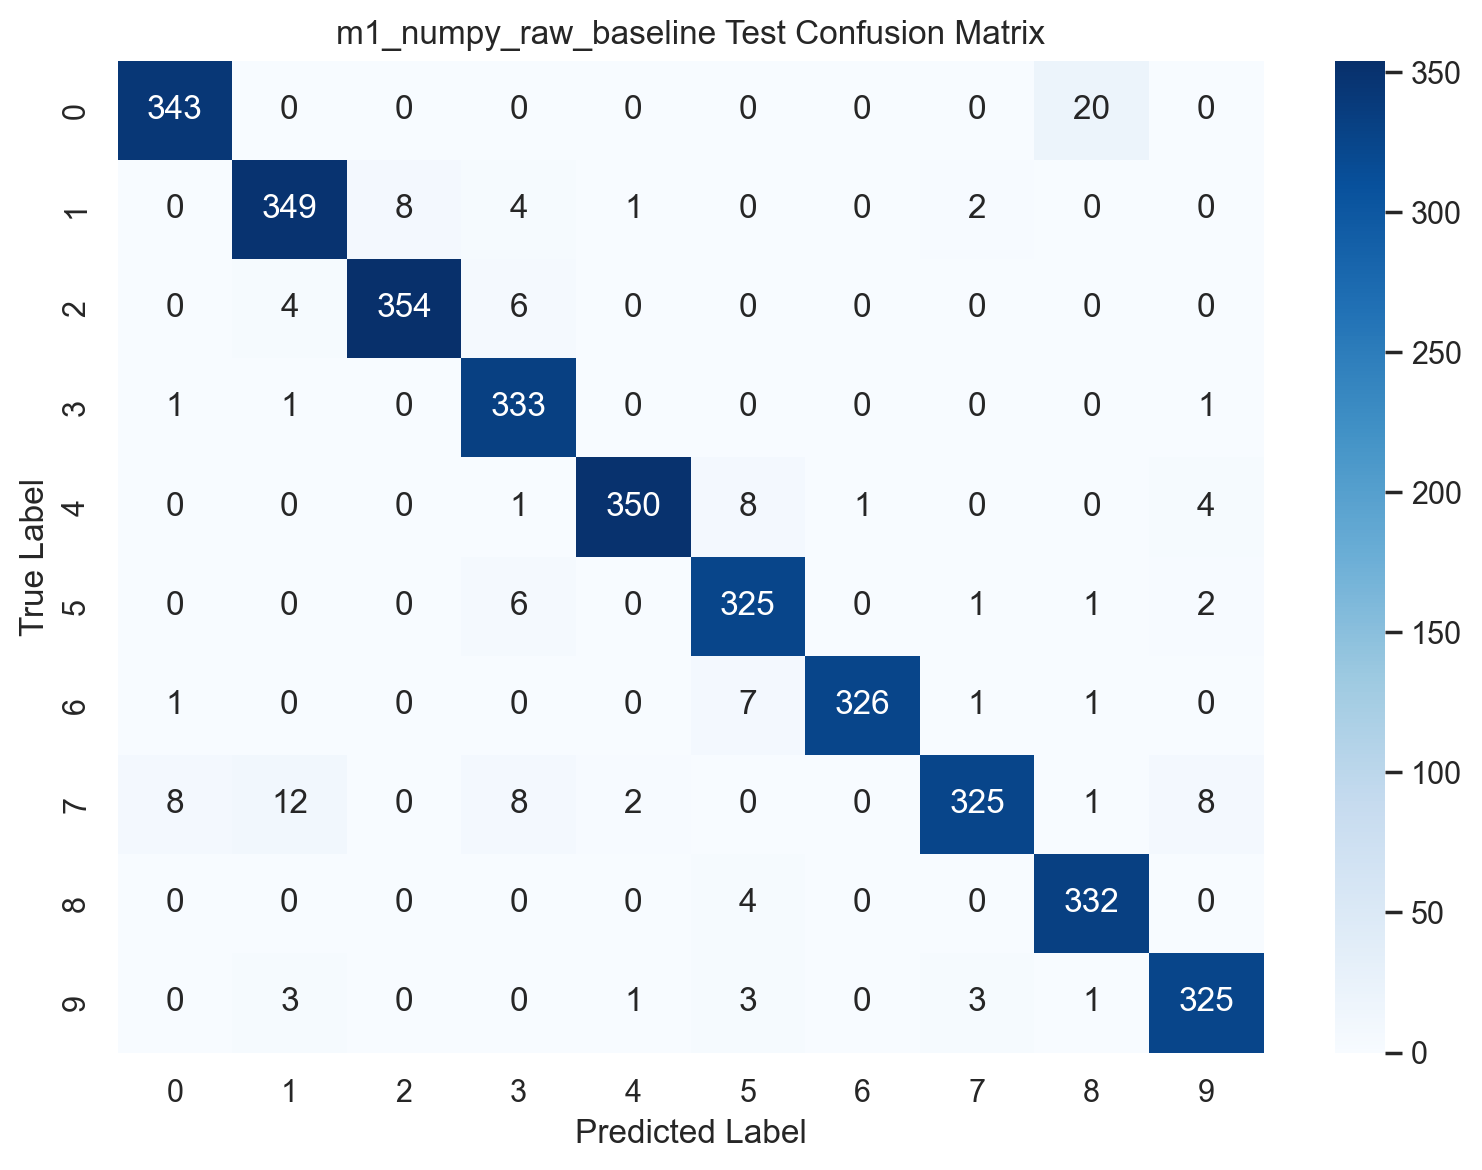

Stored 1 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\reports.
Current best overall model: m1_numpy_raw_baseline


In [3]:
m1_result = run_and_log("m1_numpy_raw_baseline")


## M2: NumPy Standardized


,name,family,hidden_layers,standardize,l2_lambda,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m2_numpy_standardized,numpy,"(32,)",True,0.0,11280,0.982655,0.948828,0.949159


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m2_numpy_standardized_history.png
Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m2_numpy_standardized_confusion_matrix.png


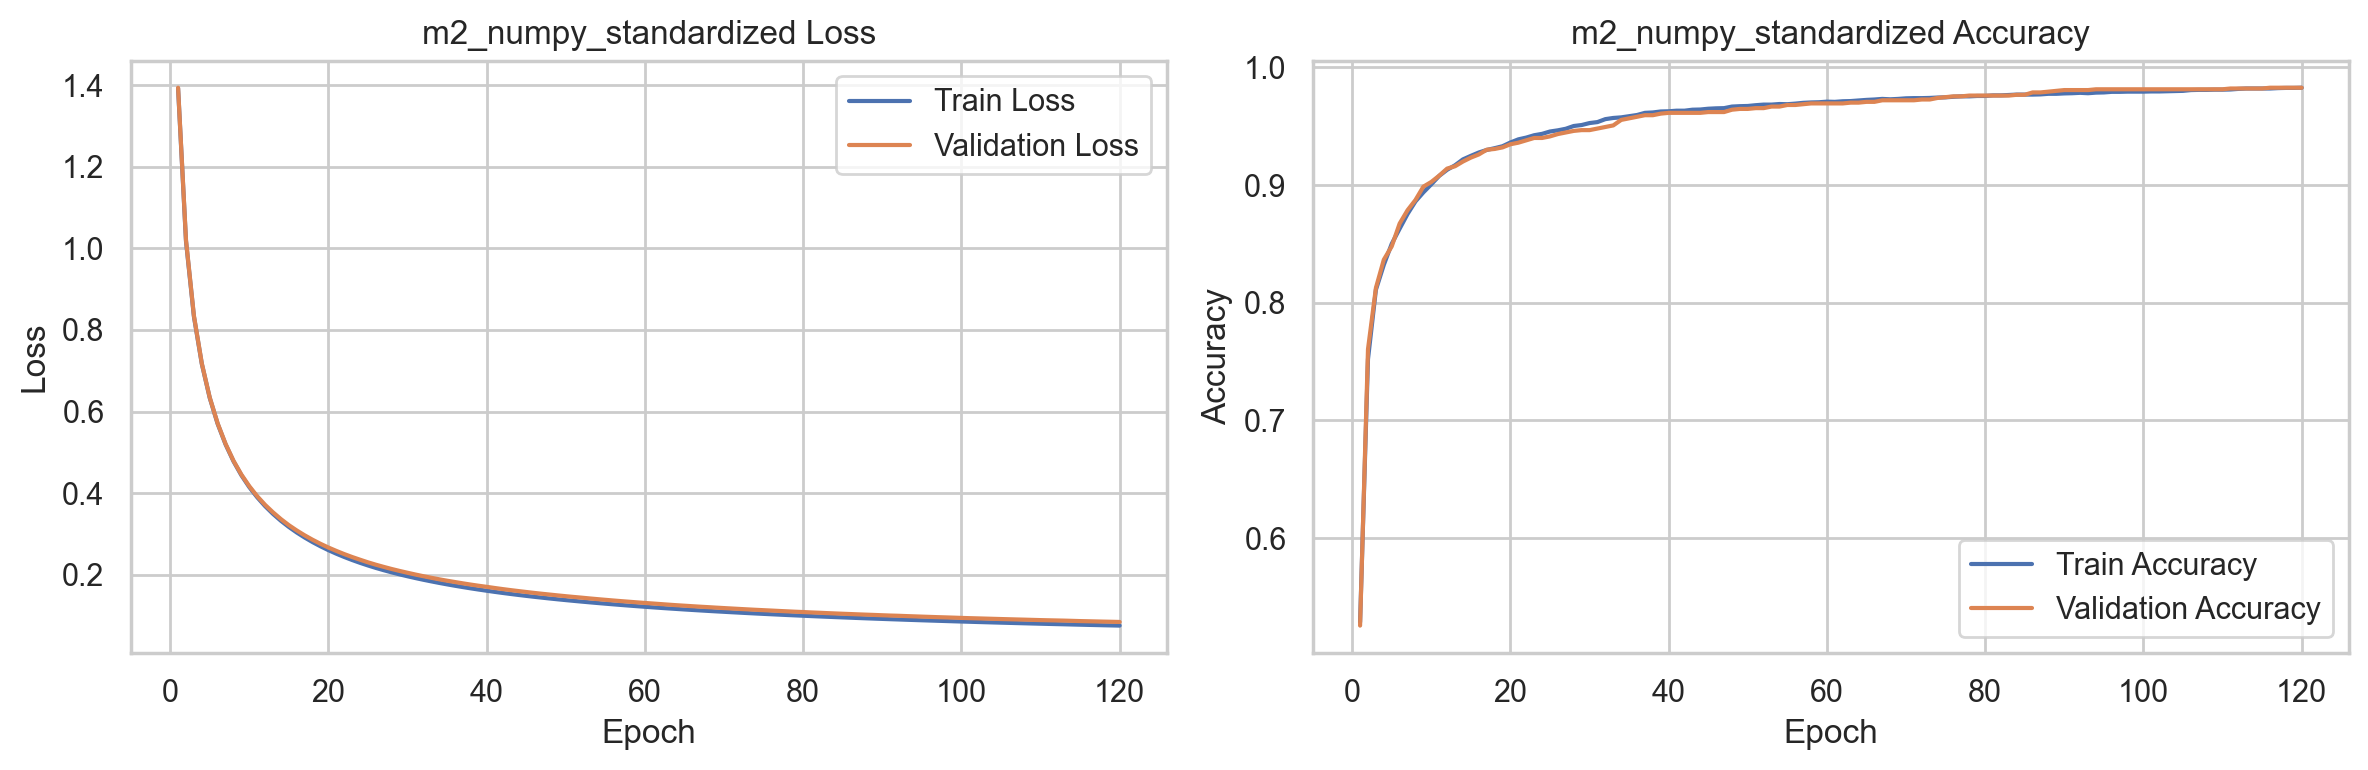

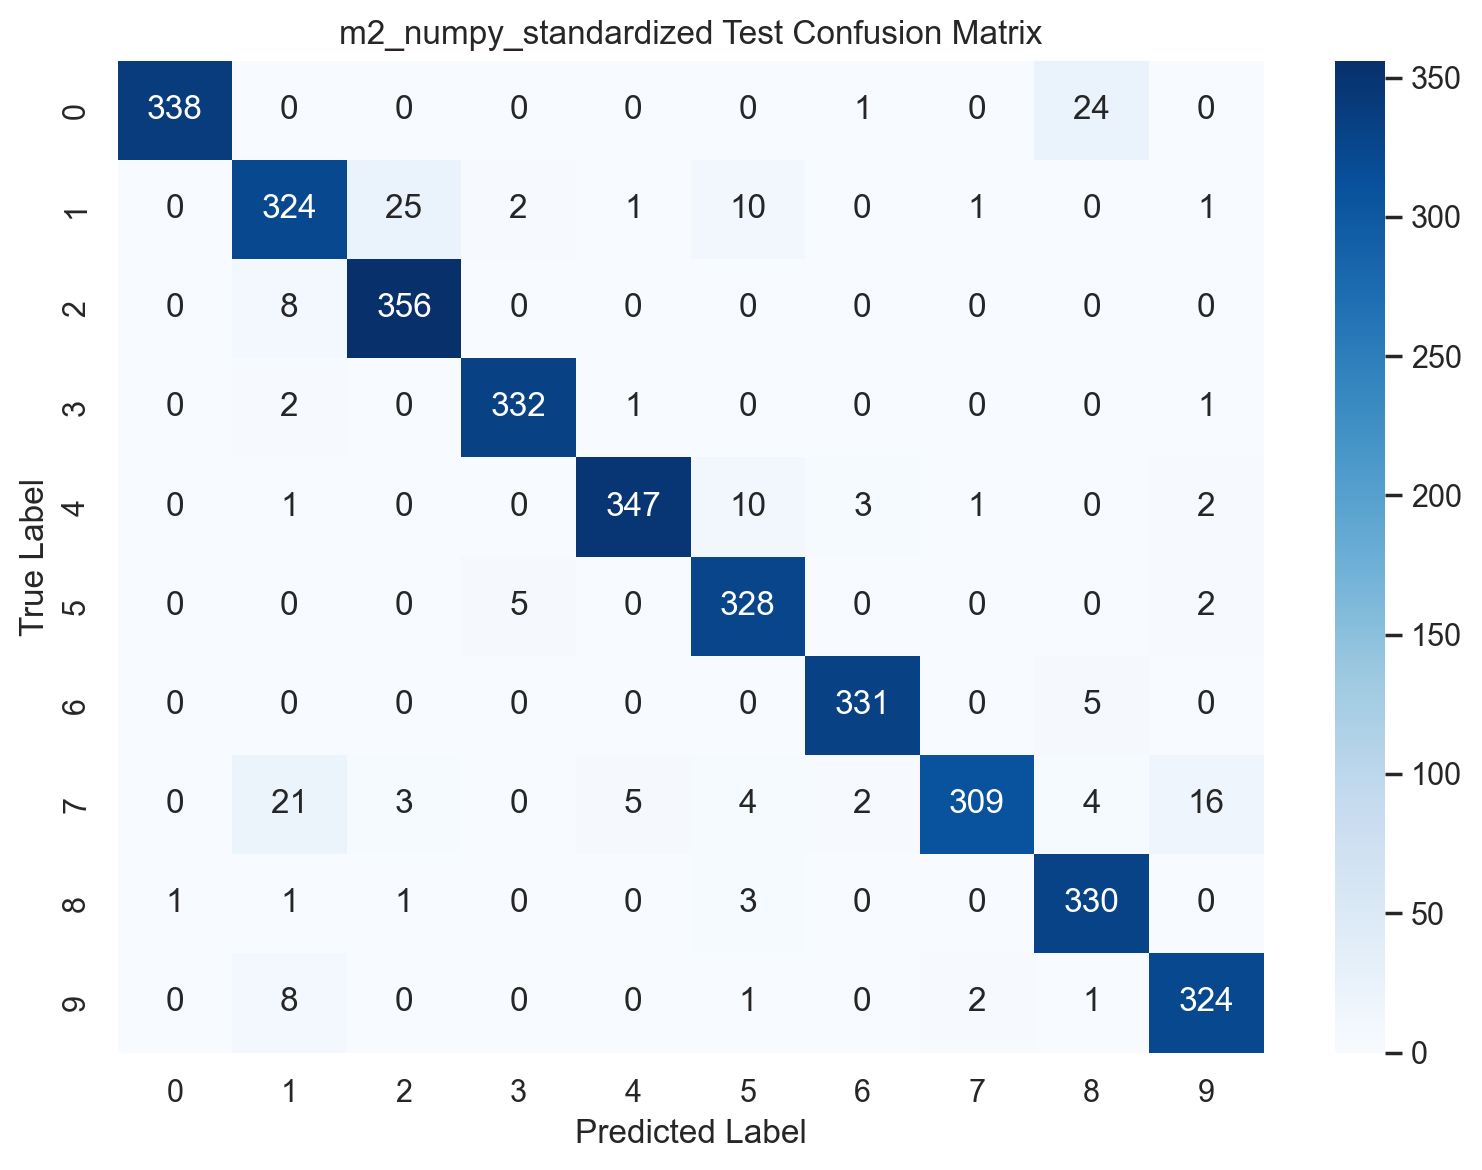

Stored 2 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\reports.
Current best overall model: m1_numpy_raw_baseline


In [4]:
m2_result = run_and_log("m2_numpy_standardized")


## M3: NumPy Deeper


,name,family,hidden_layers,standardize,l2_lambda,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m3_numpy_deeper,numpy,"(64, 32)",True,0.0,15040,0.993329,0.965695,0.965915


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m3_numpy_deeper_history.png
Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m3_numpy_deeper_confusion_matrix.png


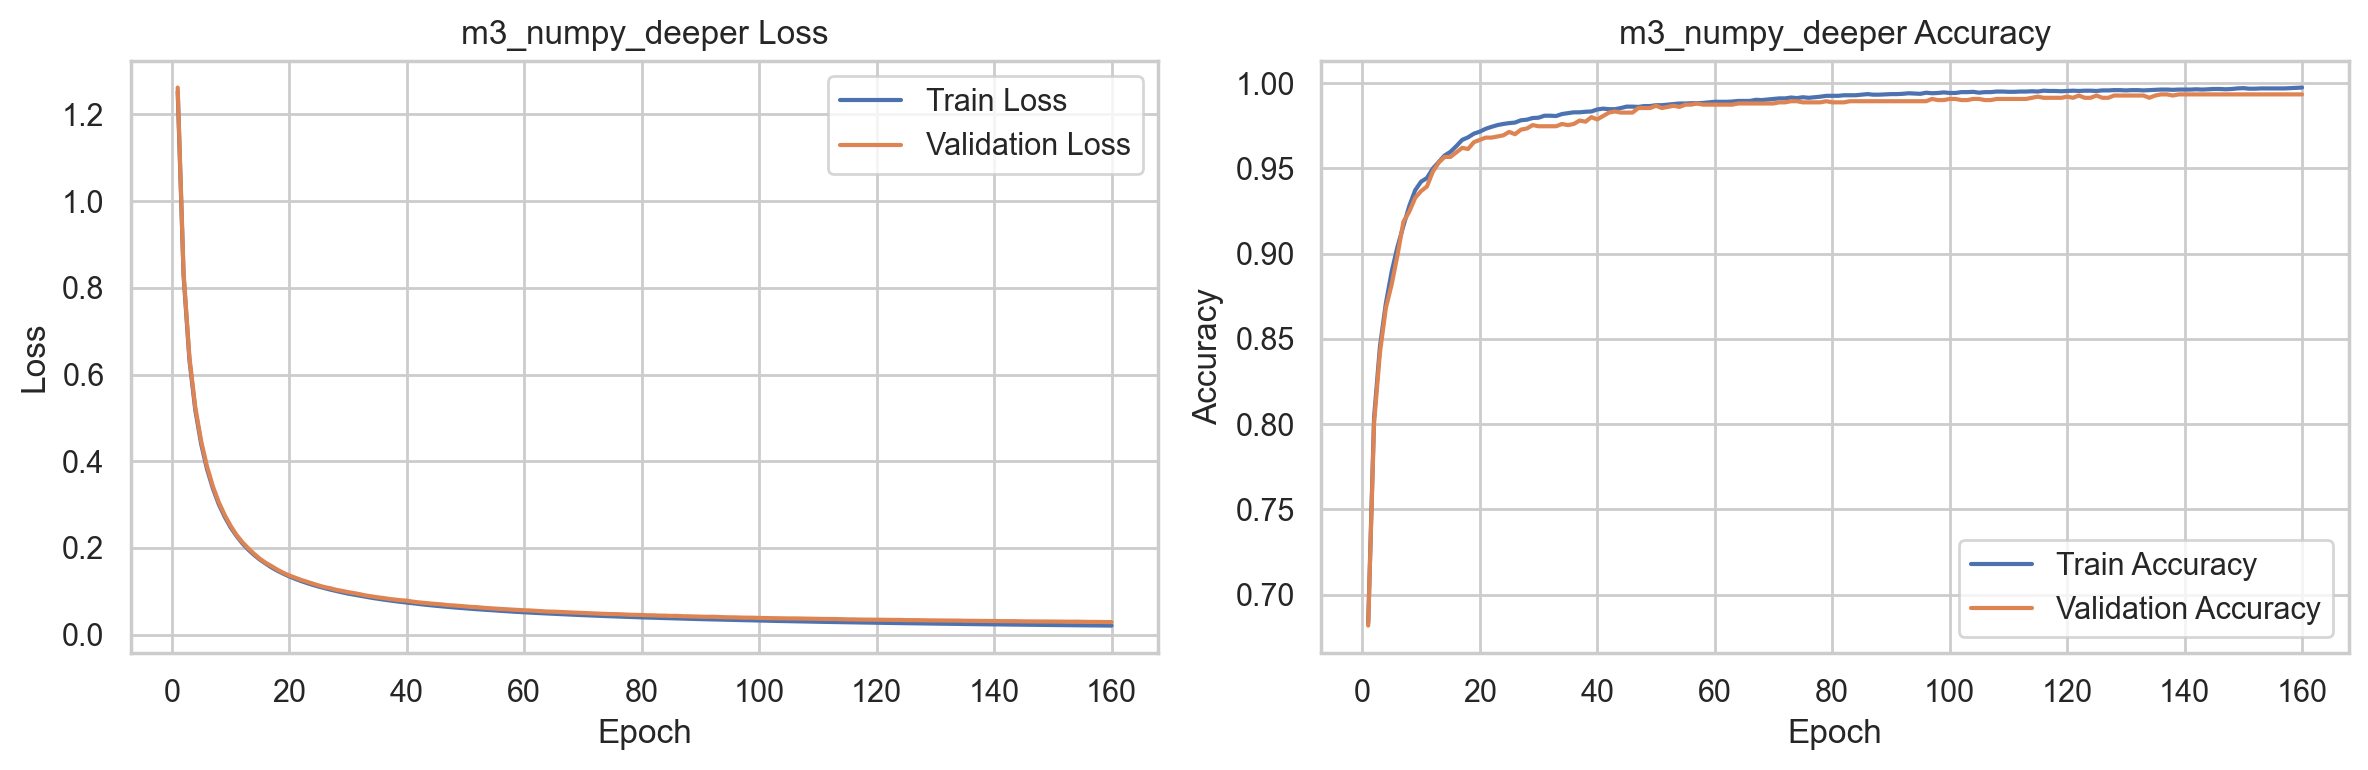

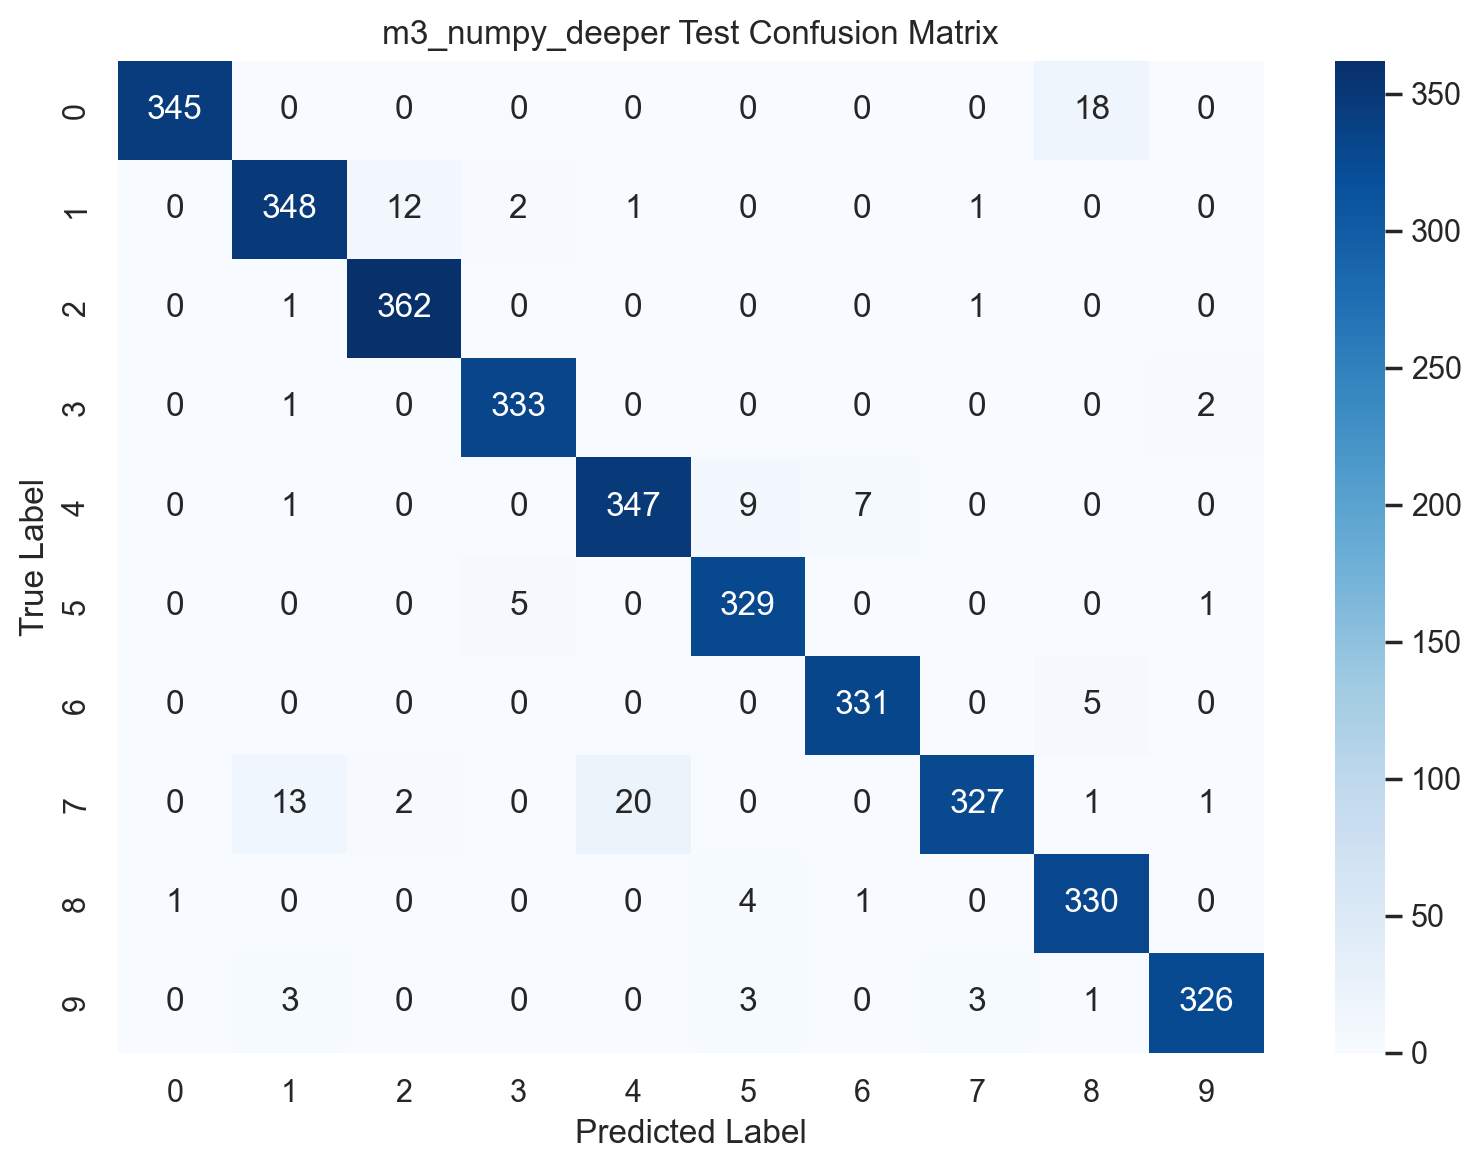

Stored 3 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\reports.
Current best overall model: m3_numpy_deeper


In [5]:
m3_result = run_and_log("m3_numpy_deeper")


## M4: NumPy Regularized


,name,family,hidden_layers,standardize,l2_lambda,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m4_numpy_regularized,numpy,"(64, 32)",True,0.0001,15040,0.993996,0.965695,0.965915


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m4_numpy_regularized_history.png
Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m4_numpy_regularized_confusion_matrix.png


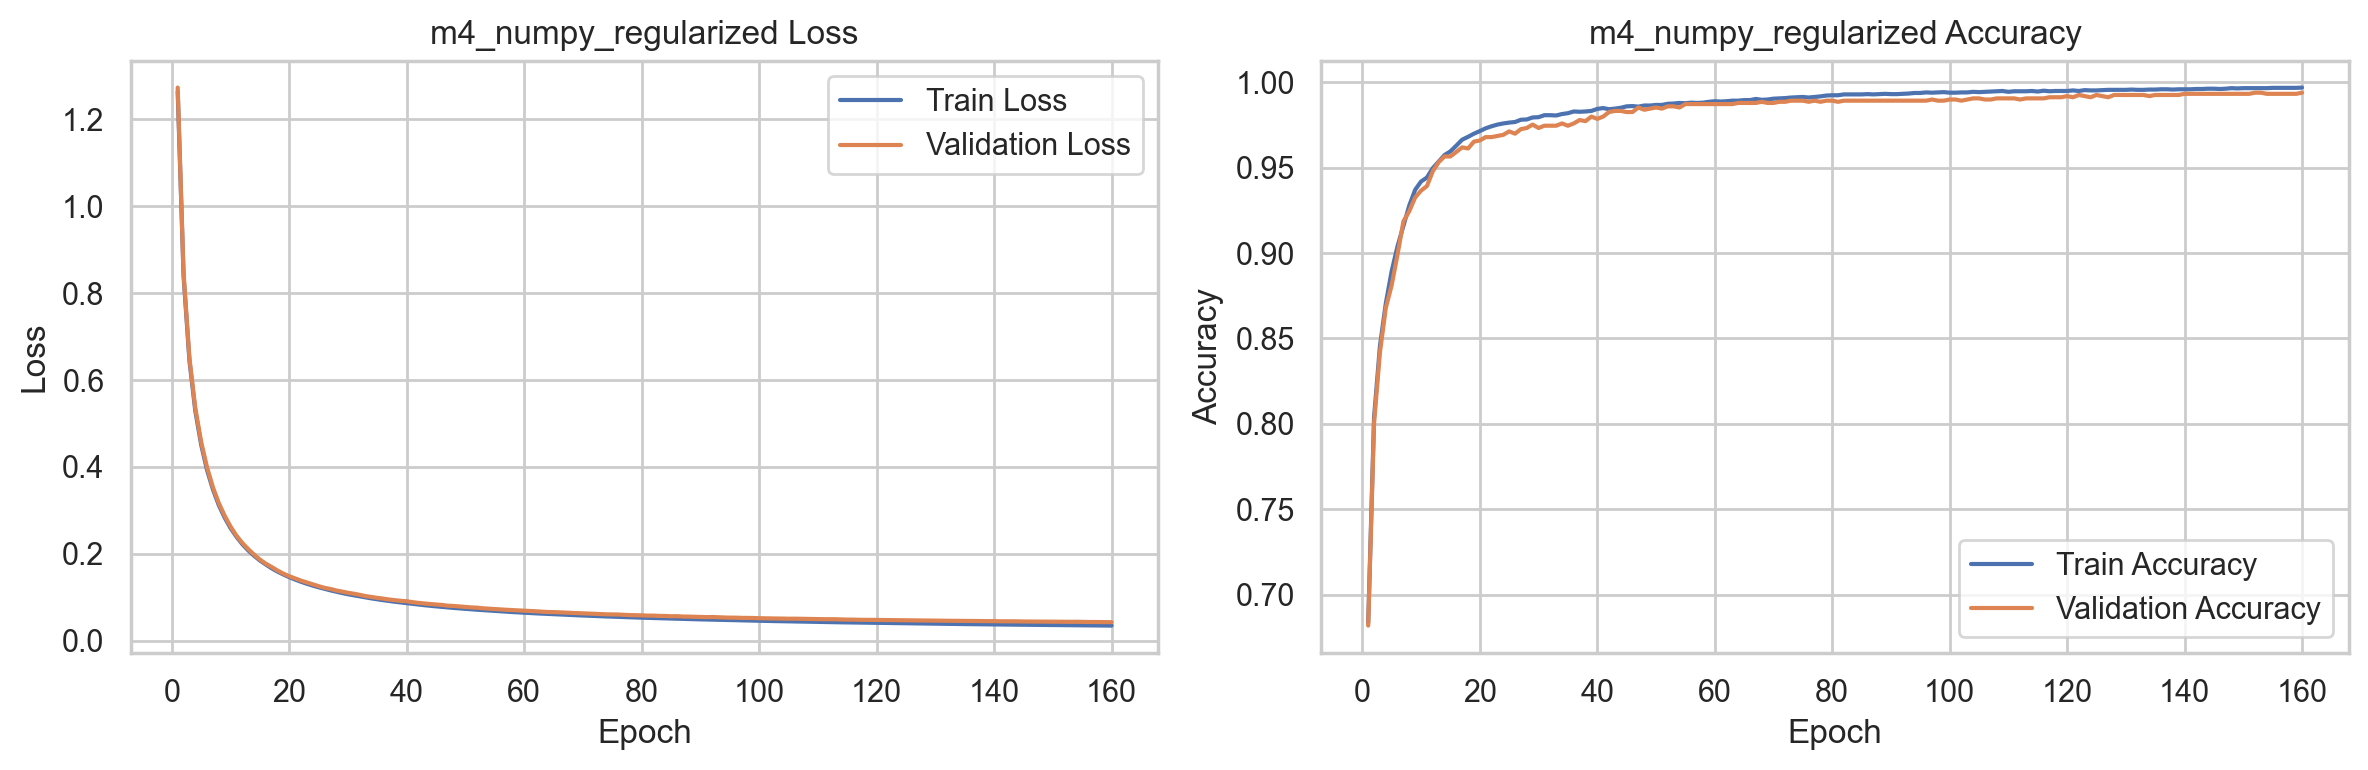

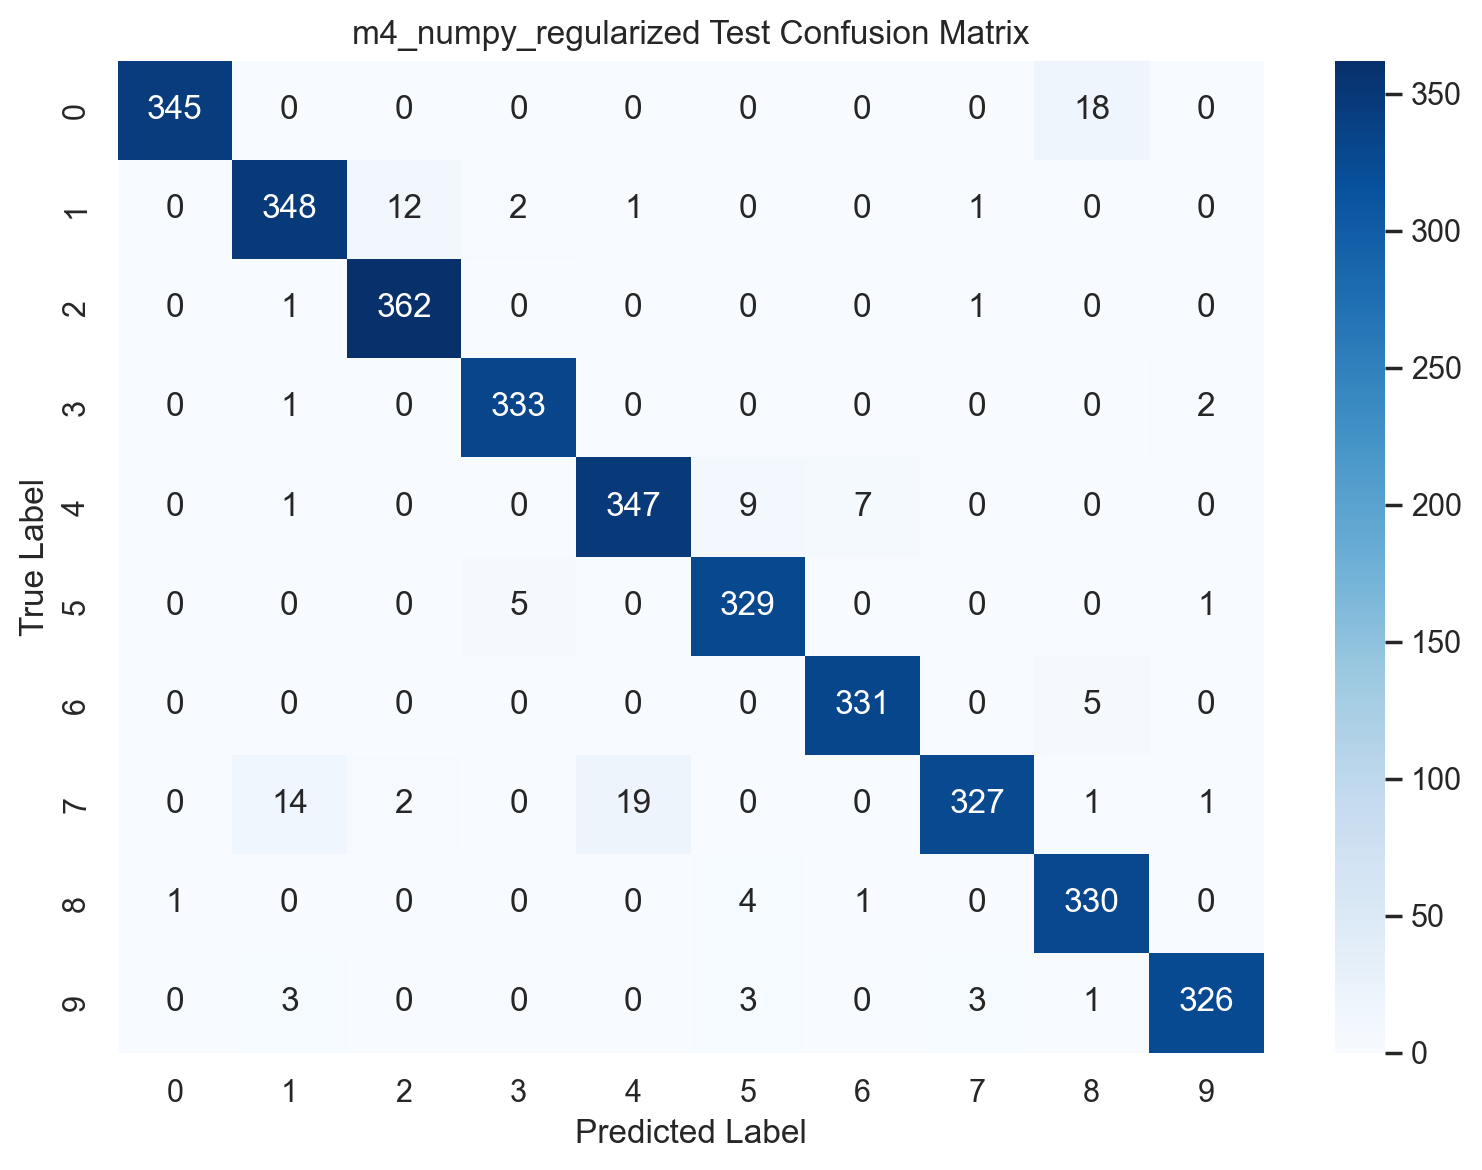

Stored 4 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\reports.
Current best overall model: m4_numpy_regularized


In [6]:
m4_result = run_and_log("m4_numpy_regularized")


## M5: scikit-learn Replica


,name,family,hidden_layers,standardize,l2_lambda,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m5_sklearn_replica,sklearn,"(64, 32)",True,0.0001,15040,0.993996,0.965409,0.965646


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m5_sklearn_replica_history.png
Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m5_sklearn_replica_confusion_matrix.png


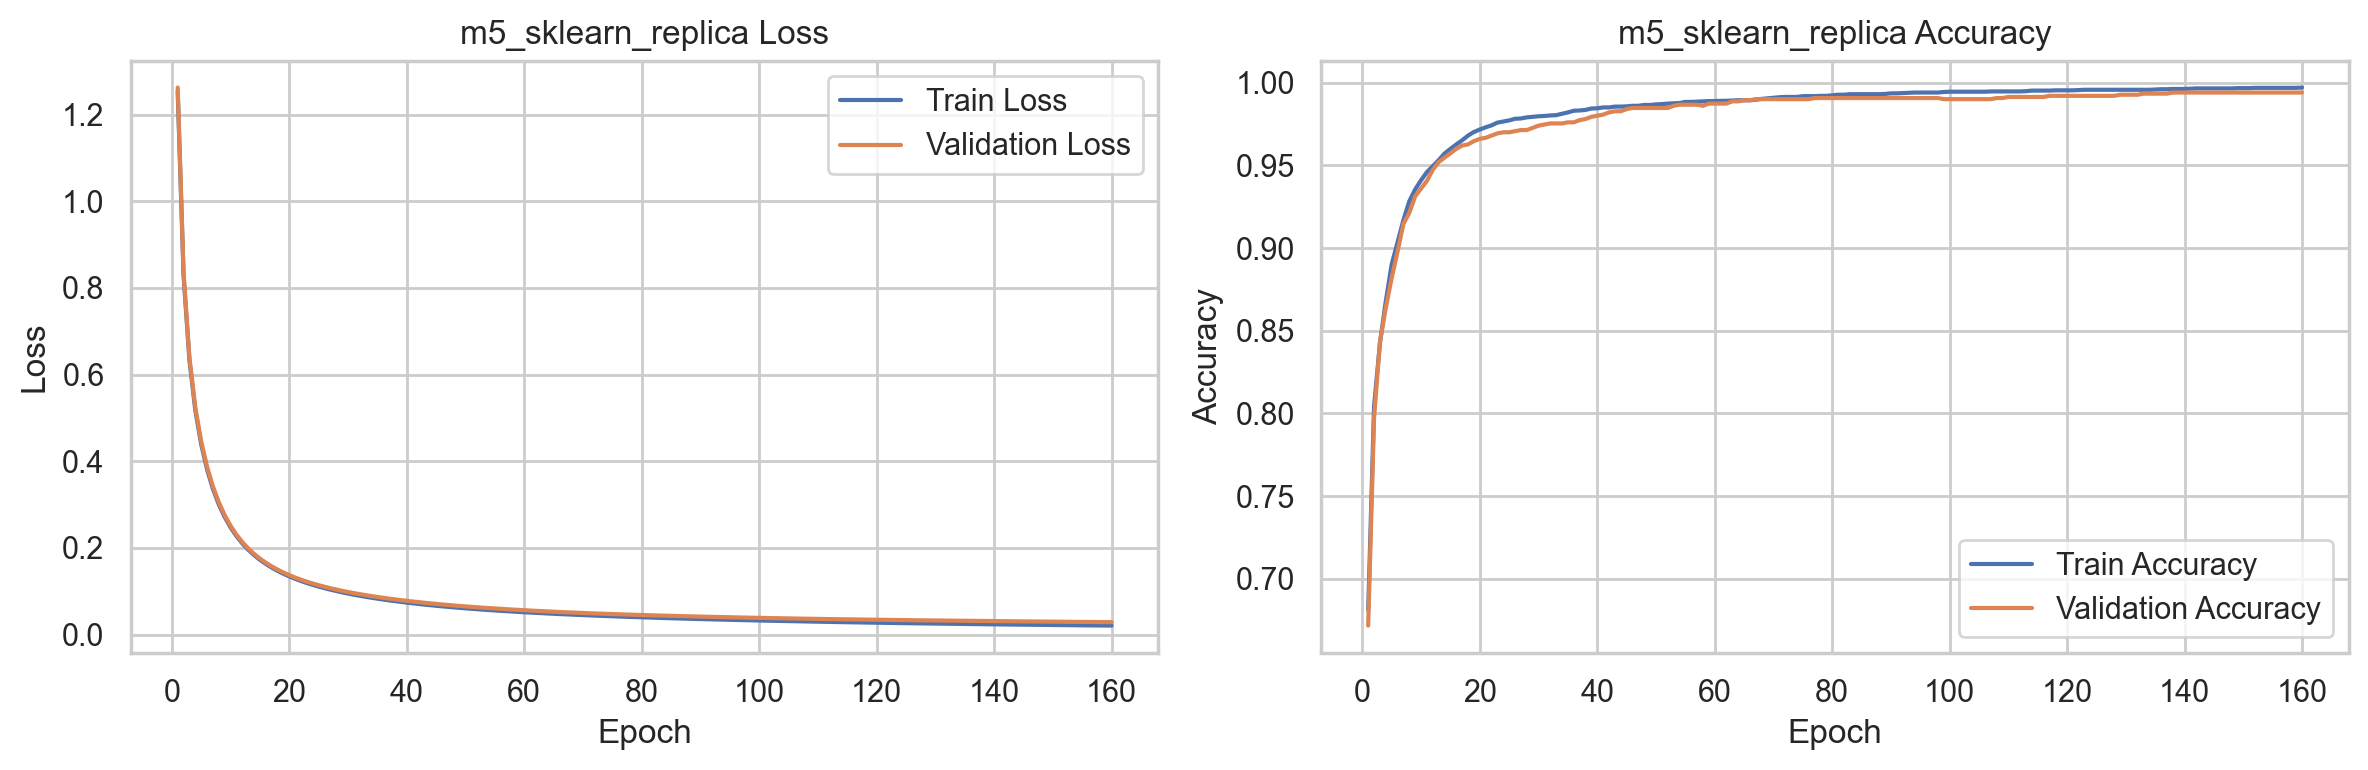

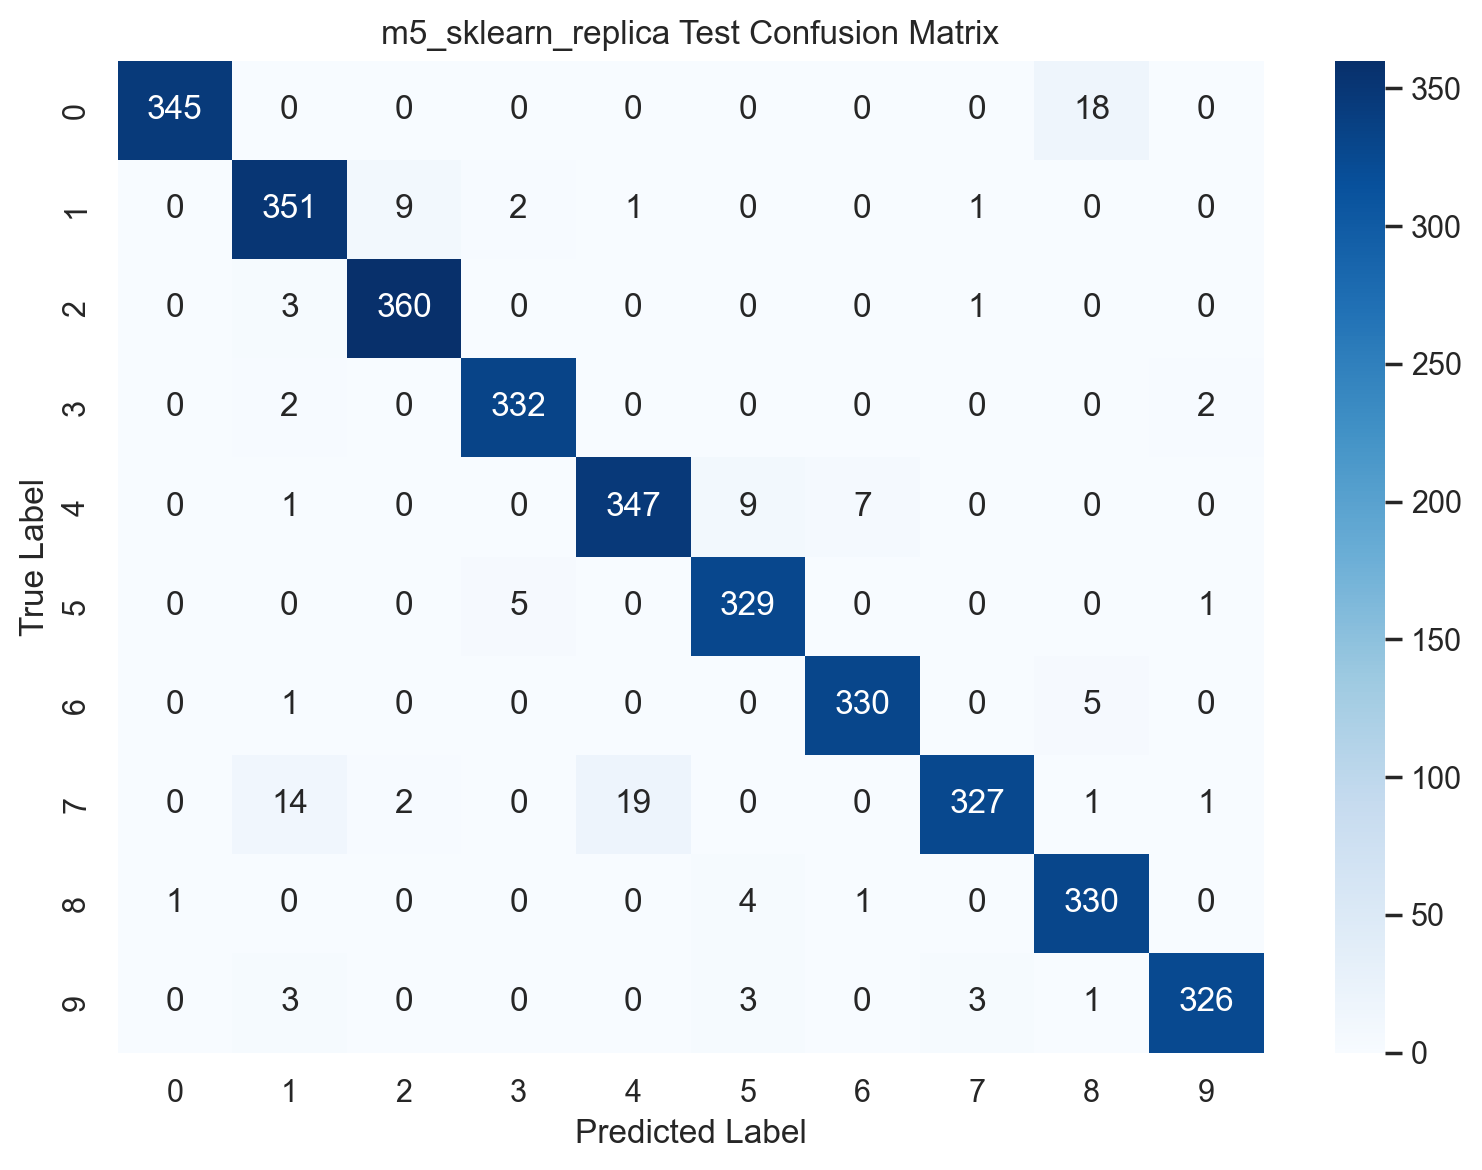

Stored 5 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\reports.
Current best overall model: m4_numpy_regularized


In [7]:
m5_result = run_and_log("m5_sklearn_replica")


## M6: PyTorch Replica


,name,family,hidden_layers,standardize,l2_lambda,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m6_pytorch_replica,pytorch,"(64, 32)",True,0.0001,15040,0.993996,0.965981,0.966201


History plot: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m6_pytorch_replica_history.png
Confusion matrix: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\figures\m6_pytorch_replica_confusion_matrix.png


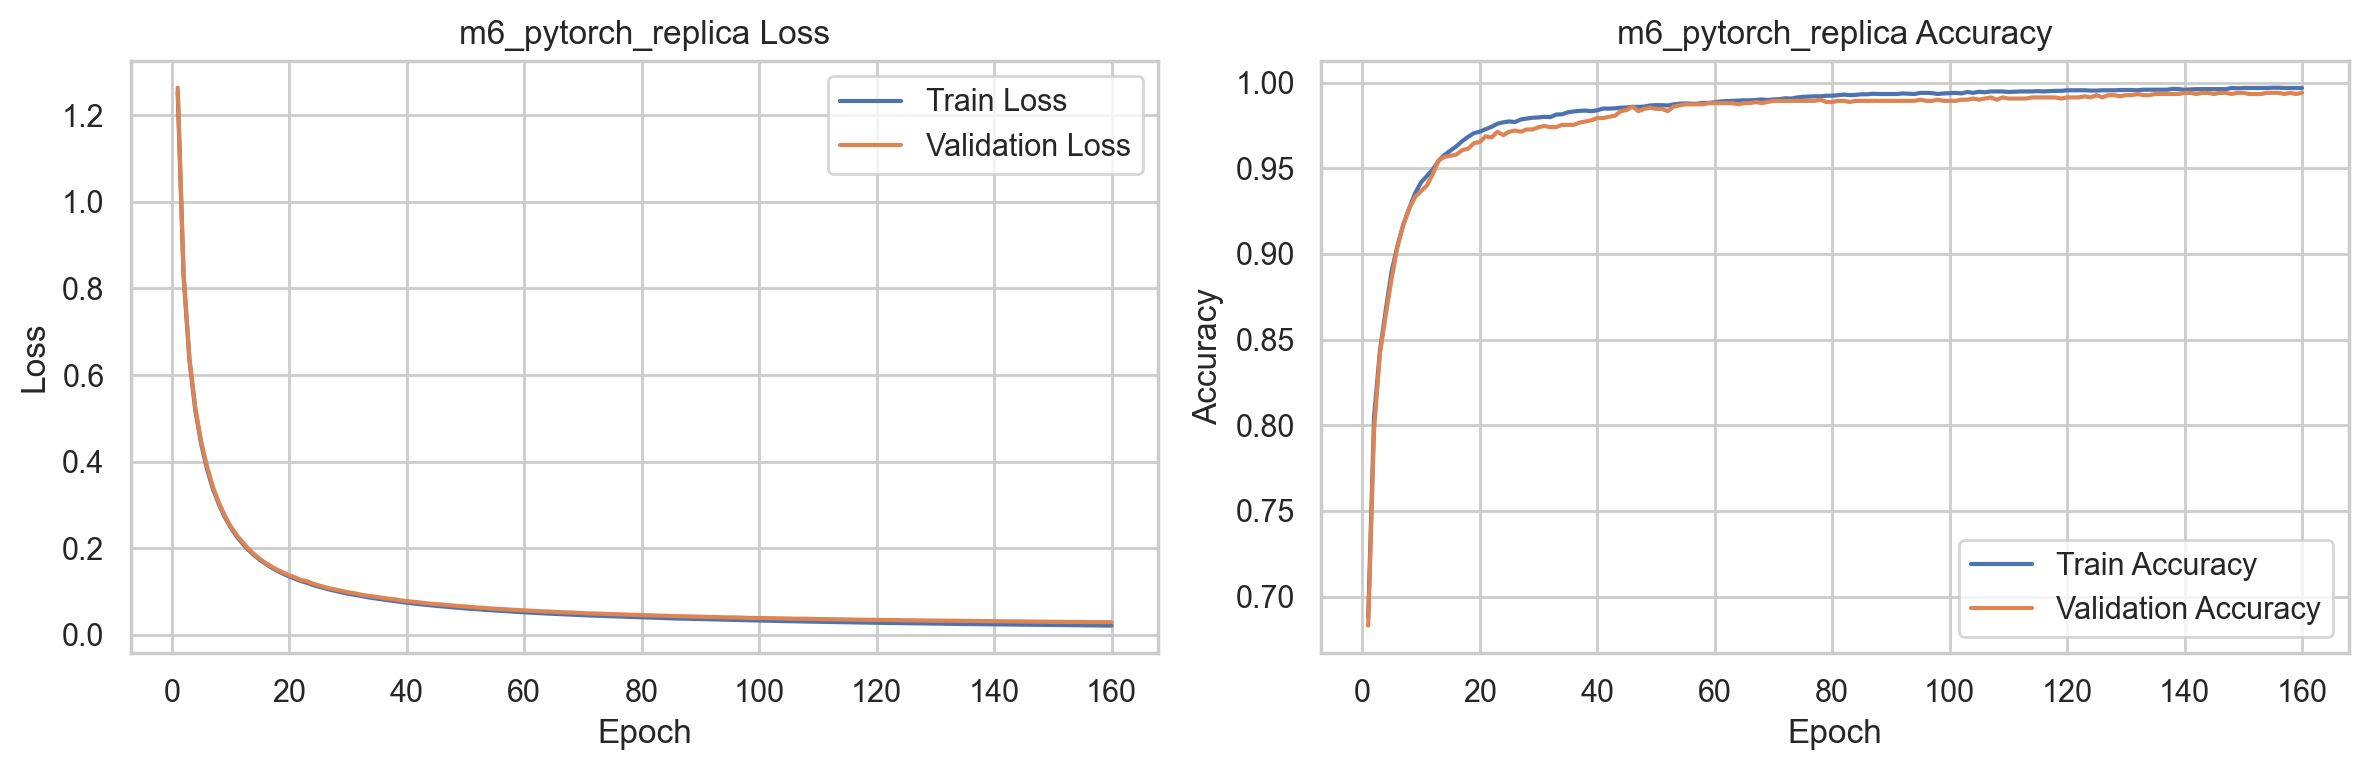

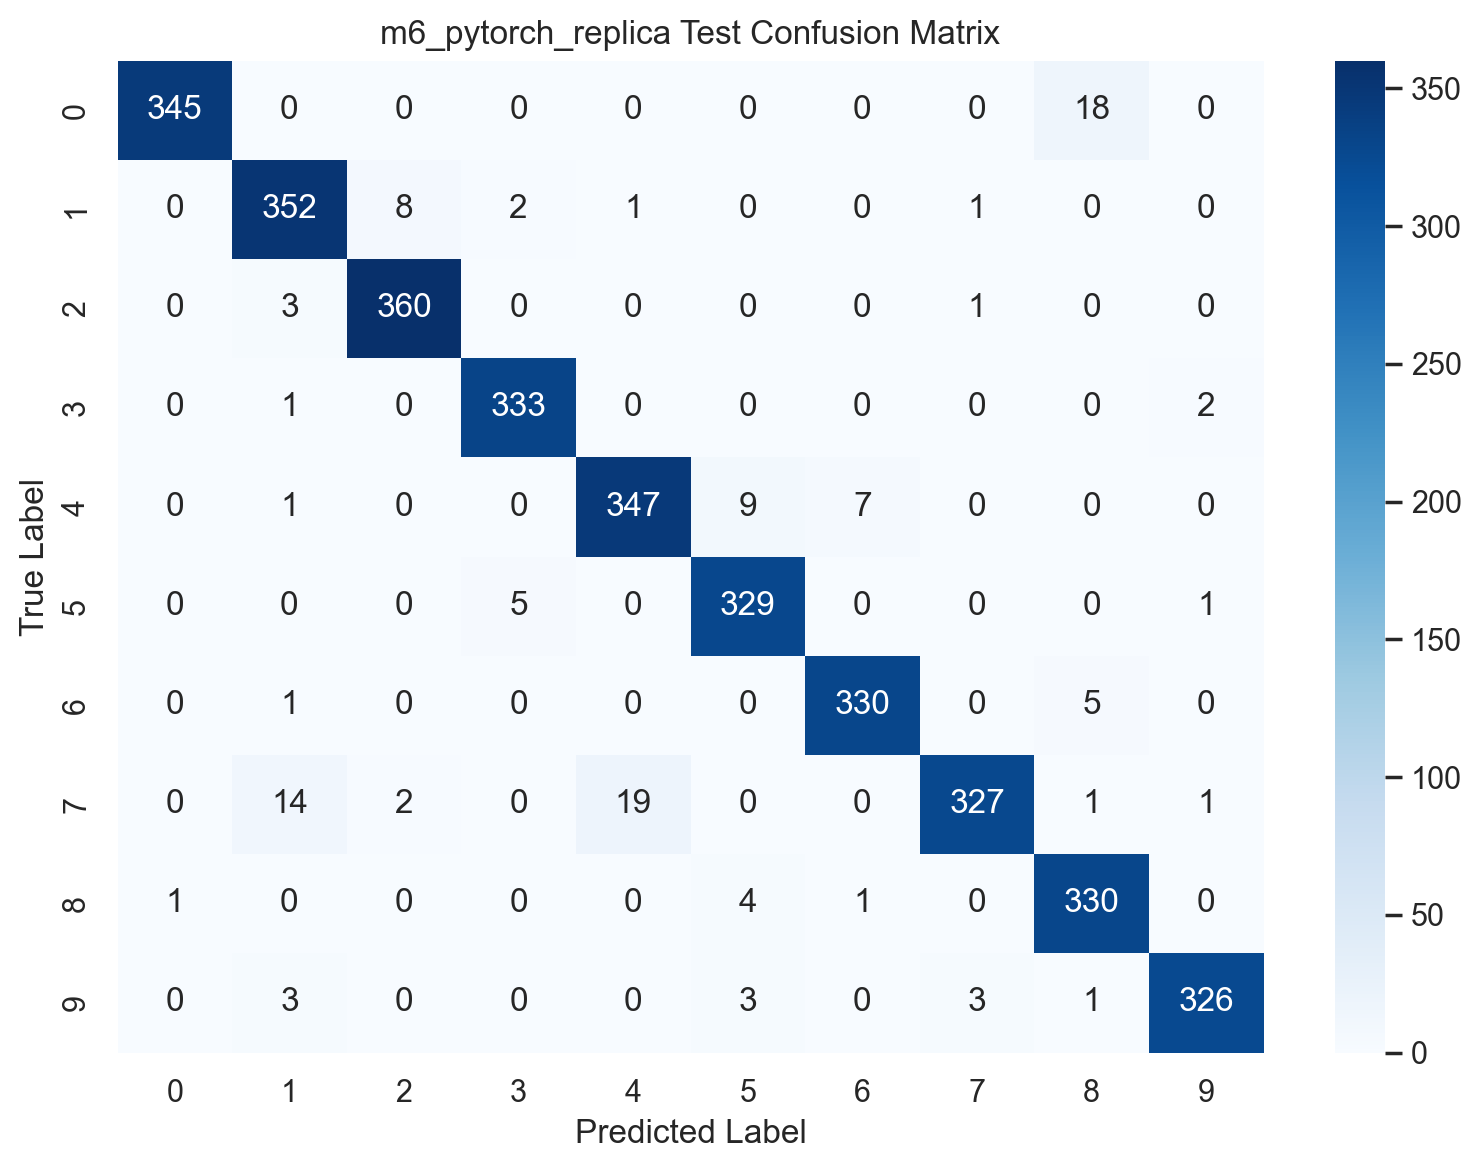

Stored 6 result(s). Reports updated in C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\reports.
Current best overall model: m4_numpy_regularized


In [8]:
m6_result = run_and_log("m6_pytorch_replica")


## Final Summary and Comparison Plot


,name,family,hidden_layers,standardize,l2_lambda,n_steps,val_accuracy,test_accuracy,test_f1_macro
0,m1_numpy_raw_baseline,numpy,"(32,)",False,0.0000,11280,0.985991,0.961121,0.961161
1,m2_numpy_standardized,numpy,"(32,)",True,0.0000,11280,0.982655,0.948828,0.949159
2,m3_numpy_deeper,numpy,"(64, 32)",True,0.0000,15040,0.993329,0.965695,0.965915
3,m4_numpy_regularized,numpy,"(64, 32)",True,0.0001,15040,0.993996,0.965695,0.965915
4,m5_sklearn_replica,sklearn,"(64, 32)",True,0.0001,15040,0.993996,0.965409,0.965646
5,m6_pytorch_replica,pytorch,"(64, 32)",True,0.0001,15040,0.993996,0.965981,0.966201


Reports written to: C:\Users\hp\OneDrive\Documents\MY PROJECTS\yzm-304-assignments\outputs\reports


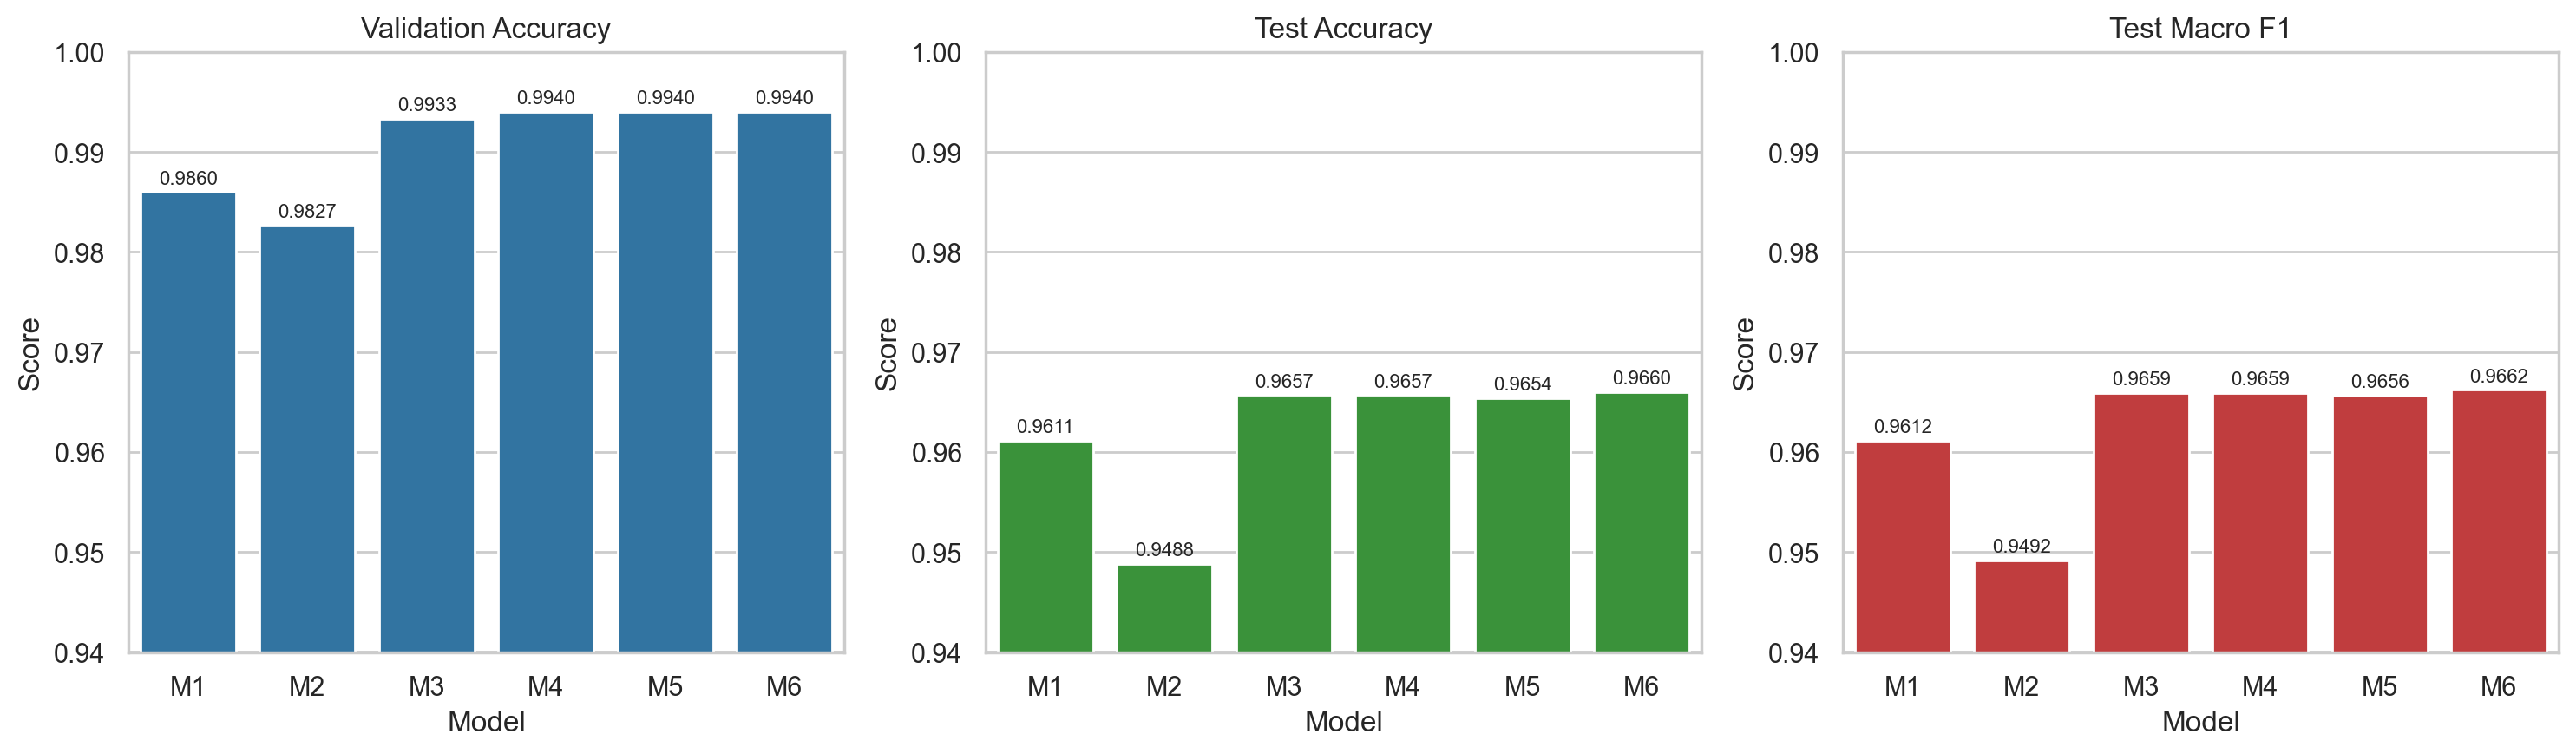

{'selection_rule': 'Highest validation accuracy wins; ties are resolved with lower n_steps.',
 'best_manual_model': {'name': 'm4_numpy_regularized',
  'family': 'numpy',
  'hidden_layers': (64, 32),
  'standardize': True,
  'learning_rate': 0.01,
  'batch_size': 64,
  'max_epochs': 160,
  'l2_lambda': 0.0001,
  'n_steps': 15040,
  'val_loss': 0.029226102003017323,
  'val_accuracy': 0.9939959973315544,
  'val_precision_macro': 0.9941025552483008,
  'val_recall_macro': 0.994017094017094,
  'val_f1_macro': 0.9940393375613172,
  'test_loss': 0.15261616713924153,
  'test_accuracy': 0.9656946826758147,
  'test_precision_macro': 0.9662864189899254,
  'test_recall_macro': 0.9663272006148533,
  'test_f1_macro': 0.9659150681418002,
  'final_train_accuracy': 0.9969974979149291,
  'final_val_accuracy': 0.9939959973315544,
  'history_path': WindowsPath('C:/Users/hp/OneDrive/Documents/MY PROJECTS/yzm-304-assignments/outputs/figures/m4_numpy_regularized_history.png'),
  'confusion_matrix_path': Windo

In [9]:
summary_frame = results_summary_frame(results)
display(summary_frame)

selection_summary = write_experiment_reports(results)
print(f"Reports written to: {REPORTS_DIR}")
display(Image(filename="outputs/figures/model_metric_comparison.png"))

selection_summary
